In [6]:
%load_ext autoreload
%reload_ext autoreload
%autoreload 2

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from network_idx.config import GCS_PROJECT_ID, BQ_DATASET_FEATURES, BQ_DATASET_ANALYTICS, BQ_FEATURES_ENGG_TRACT
from google.cloud import bigquery
from network_idx.utils import check_and_authenticate

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [49]:
# Extract base table with total parcel counts per tract
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_FEATURES}.loc_parcels_growth_ct"
client = bigquery.Client(project=GCS_PROJECT_ID)
query = f"""SELECT * FROM `{table_id}`"""
tract_df_overall = client.query(query).to_arrow().to_pandas()
tract_df_overall.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 85062 entries, 0 to 85061
Data columns (total 14 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   tract_id                     85062 non-null  str    
 1   total_parcels                85062 non-null  int64  
 2   growth_parcels               85062 non-null  int64  
 3   pre_early_dev_parcels        85062 non-null  int64  
 4   unique_locations             85062 non-null  int64  
 5   builder_developer_count      85062 non-null  int64  
 6   landuse_change_count         85062 non-null  int64  
 7   building_permit_count        85062 non-null  int64  
 8   new_clip_count               85062 non-null  int64  
 9   parcel_split_count           85062 non-null  int64  
 10  total_flags                  85062 non-null  int64  
 11  flags_minus_greatest         85062 non-null  int64  
 12  mean_dist_nearest_hotspot_m  63849 non-null  float64
 13  median_dist_nearest_hotspot

In [39]:
# Examine distribution of parcels across tracts
col = "total_parcels"
print(tract_df_overall[col].describe().round(2).to_string())
print("="*50)
print(f"90th percentile: {tract_df_overall[col].quantile(0.9):.2f}")
print(f"95th percentile: {tract_df_overall[col].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df_overall[col].quantile(0.99):.2f}")
print(f"99.5th percentile: {tract_df_overall[col].quantile(0.995):.2f}")

count    85062.00
mean      1814.94
std       1480.54
min          1.00
25%        975.00
50%       1545.00
75%       2298.00
max      66671.00
90th percentile: 3327.90
95th percentile: 4154.00
99th percentile: 6516.39
99.5th percentile: 7904.08


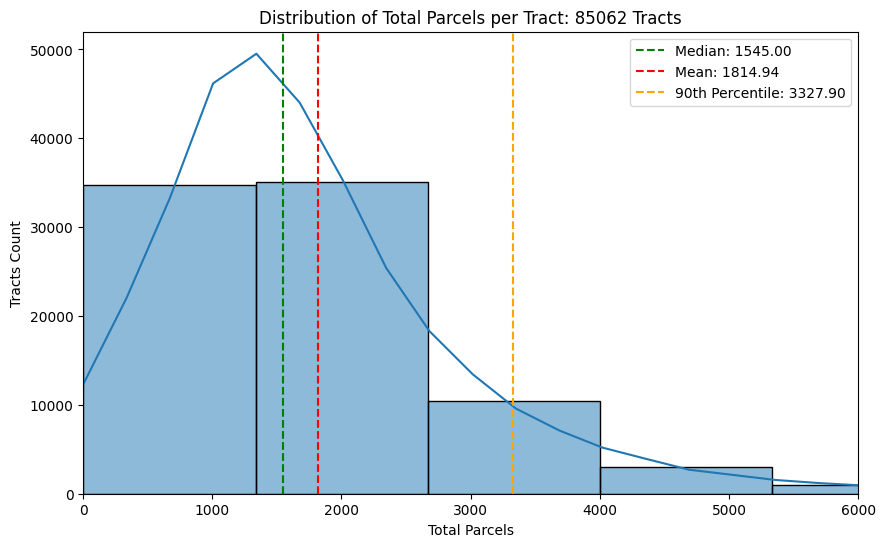

In [40]:
# Draw histrogram of total_parcels
plt.figure(figsize=(10,6))
sns.histplot(tract_df_overall[col], bins=50, kde=True)
plt.axvline(tract_df_overall[col].median(), color='green', linestyle='--', label=f'Median: {tract_df_overall[col].median():.2f}')
plt.axvline(tract_df_overall[col].mean(), color='red', linestyle='--', label=f'Mean: {tract_df_overall[col].mean():.2f}')
plt.axvline(tract_df_overall[col].quantile(0.90), color='orange', linestyle='--', label=f'90th Percentile: {tract_df_overall[col].quantile(0.9):.2f}')
plt.legend()
plt.title(f"Distribution of Total Parcels per Tract: {tract_df_overall.shape[0]} Tracts")
plt.xlabel("Total Parcels")
plt.ylabel("Tracts Count")
plt.xlim(0, 6000)  # Focus on the range with most data
plt.show()

In [41]:
# Examine distribution of parcels across tracts
col = "growth_parcels"
print(tract_df_overall[col].describe().round(2).to_string())
print("="*50)
print(f"90th percentile: {tract_df_overall[col].quantile(0.9):.2f}")
print(f"95th percentile: {tract_df_overall[col].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df_overall[col].quantile(0.99):.2f}")
print(f"99.5th percentile: {tract_df_overall[col].quantile(0.995):.2f}")

count    85062.00
mean        74.08
std        220.42
min          0.00
25%          4.00
50%         17.00
75%         62.00
max       7477.00
90th percentile: 157.00
95th percentile: 267.00
99th percentile: 1089.39
99.5th percentile: 1669.47


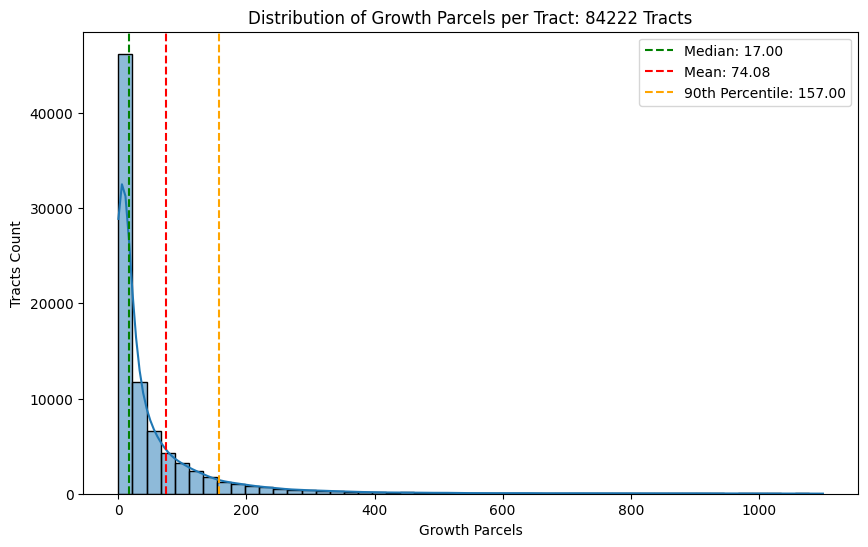

In [42]:
# Draw histogram of growth_parcels
plt.figure(figsize=(10,6))
data = tract_df_overall[tract_df_overall[col] <= 1100][col]
sns.histplot(data, bins=50, kde=True)
plt.axvline(tract_df_overall[col].median(), color='green', linestyle='--', label=f'Median: {tract_df_overall[col].median():.2f}')
plt.axvline(tract_df_overall[col].mean(), color='red', linestyle='--', label=f'Mean: {tract_df_overall[col].mean():.2f}')
plt.axvline(tract_df_overall[col].quantile(0.90), color='orange', linestyle='--', label=f'90th Percentile: {tract_df_overall[col].quantile(0.9):.2f}')
plt.legend()
plt.title(f"Distribution of Growth Parcels per Tract: {data.shape[0]} Tracts")
plt.xlabel("Growth Parcels")
plt.ylabel("Tracts Count")
plt.show()

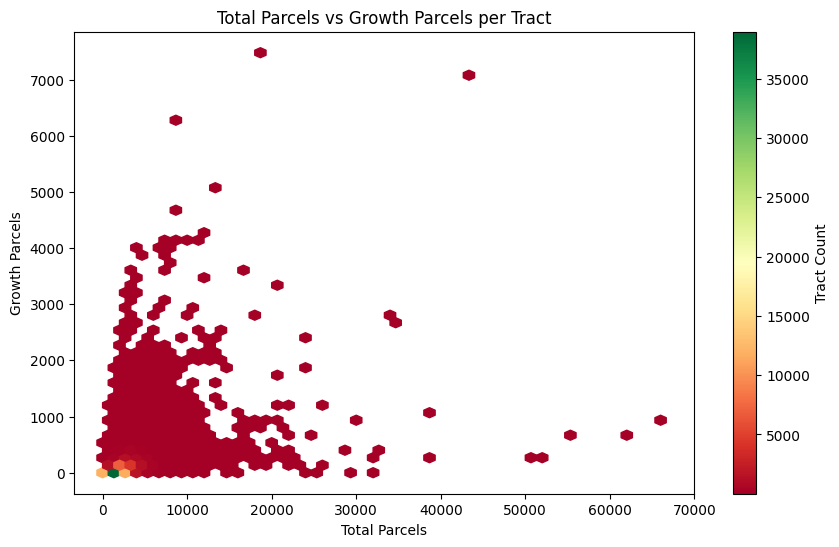

In [43]:
# Scatter with density plot
plt.figure(figsize=(10,6))
plt.hexbin(tract_df_overall['total_parcels'], tract_df_overall['growth_parcels'], 
           gridsize=50, cmap='RdYlGn', mincnt=1)
plt.colorbar(label='Tract Count')
plt.xlabel("Total Parcels")
plt.ylabel("Growth Parcels")
plt.title("Total Parcels vs Growth Parcels per Tract")
plt.show()

In [44]:
# Create quadrants based on median values
med_total = tract_df_overall['total_parcels'].median()
med_growth = tract_df_overall['growth_parcels'].median()
total_tracts = len(tract_df_overall)

quadrants = pd.DataFrame([
    {'Total Parcels': 'High', 'Growth': 'High', 
     'Census Tracts': ((tract_df_overall['total_parcels'] >= med_total) & (tract_df_overall['growth_parcels'] >= med_growth)).sum()},
    {'Total Parcels': 'High', 'Growth': 'Low', 
     'Census Tracts': ((tract_df_overall['total_parcels'] >= med_total) & (tract_df_overall['growth_parcels'] < med_growth)).sum()},
    {'Total Parcels': 'Low', 'Growth': 'High', 
     'Census Tracts': ((tract_df_overall['total_parcels'] < med_total) & (tract_df_overall['growth_parcels'] >= med_growth)).sum()},
    {'Total Parcels': 'Low', 'Growth': 'Low', 
     'Census Tracts': ((tract_df_overall['total_parcels'] < med_total) & (tract_df_overall['growth_parcels'] < med_growth)).sum()},
])

quadrants['% of Total'] = (quadrants['Census Tracts'] / total_tracts * 100).round(1).astype(str) + '%'

print(f"Median Total Parcels: {med_total:.0f} | Median Growth Parcels: {med_growth:.0f}")
print("=" * 60)
quadrants

Median Total Parcels: 1545 | Median Growth Parcels: 17


,Total Parcels,Growth,Census Tracts,% of Total
0,High,High,31517,37.1%
1,High,Low,11042,13.0%
2,Low,High,11721,13.8%
3,Low,Low,30782,36.2%


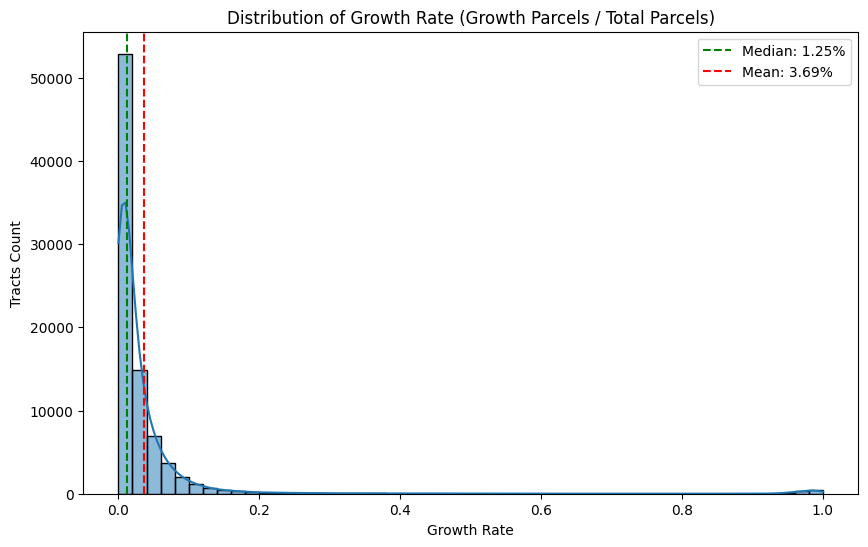

In [45]:
# Growth rate distribution
tract_df_overall['growth_rate'] = tract_df_overall['growth_parcels'] / tract_df_overall['total_parcels']

plt.figure(figsize=(10,6))
sns.histplot(tract_df_overall['growth_rate'].dropna(), bins=50, kde=True)
plt.axvline(tract_df_overall['growth_rate'].median(), color='green', linestyle='--', 
            label=f"Median: {tract_df_overall['growth_rate'].median():.2%}")
plt.axvline(tract_df_overall['growth_rate'].mean(), color='red', linestyle='--', 
            label=f"Mean: {tract_df_overall['growth_rate'].mean():.2%}")
plt.legend()
plt.title("Distribution of Growth Rate (Growth Parcels / Total Parcels)")
plt.xlabel("Growth Rate")
plt.ylabel("Tracts Count")
plt.show()

In [46]:
# Correlation analysis
print(f"Pearson correlation: {tract_df_overall['total_parcels'].corr(tract_df_overall['growth_parcels']):.3f}")
print(f"Spearman correlation: {tract_df_overall['total_parcels'].corr(tract_df_overall['growth_parcels'], method='spearman'):.3f}")
print(f"Mean growth rate: {tract_df_overall['growth_rate'].mean():.2%}")
print(f"Median growth rate: {tract_df_overall['growth_rate'].median():.2%}")

Pearson correlation: 0.340
Spearman correlation: 0.636
Mean growth rate: 3.69%
Median growth rate: 1.25%


In [50]:
# Check distribution of builder_developer_count
print(tract_df_overall['builder_developer_count'].describe().round(2).to_string())
print("="*50)
print(f"90th percentile: {tract_df_overall['builder_developer_count'].quantile(0.9):.2f}")
print(f"95th percentile: {tract_df_overall['builder_developer_count'].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df_overall['builder_developer_count'].quantile(0.99):.2f}")
print(f"99.5th percentile: {tract_df_overall['builder_developer_count'].quantile(0.995):.2f}")

count    85062.00
mean         6.26
std         44.73
min          0.00
25%          0.00
50%          0.00
75%          2.00
max       7238.00
90th percentile: 9.00
95th percentile: 23.00
99th percentile: 115.00
99.5th percentile: 188.00


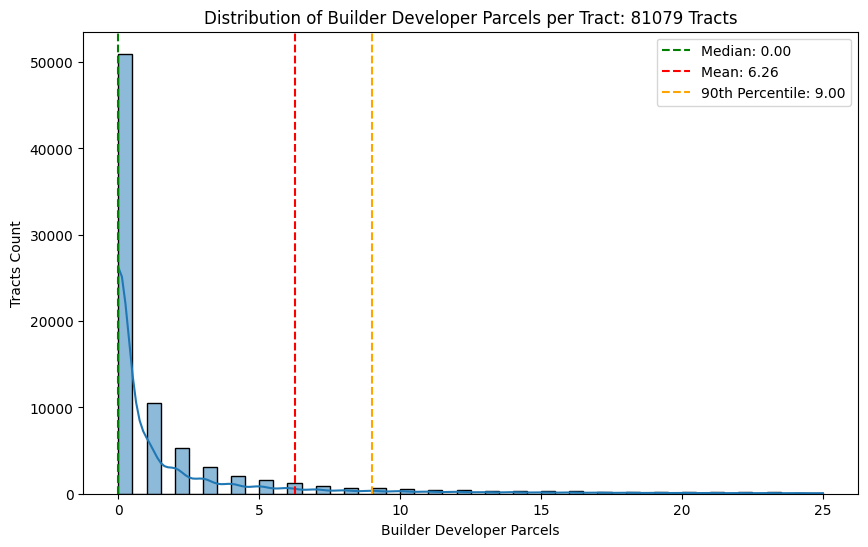

In [51]:
# Distribution of builder_developer_count
col = 'builder_developer_count'
plt.figure(figsize=(10,6))
data = tract_df_overall[tract_df_overall[col] <= 25][col]
sns.histplot(data, bins=50, kde=True)
plt.axvline(tract_df_overall[col].median(), color='green', linestyle='--', label=f'Median: {tract_df_overall[col].median():.2f}')
plt.axvline(tract_df_overall[col].mean(), color='red', linestyle='--', label=f'Mean: {tract_df_overall[col].mean():.2f}')
plt.axvline(tract_df_overall[col].quantile(0.90), color='orange', linestyle='--', label=f'90th Percentile: {tract_df_overall[col].quantile(0.9):.2f}')
plt.legend()
plt.title(f"Distribution of Builder Developer Parcels per Tract: {data.shape[0]} Tracts")
plt.xlabel("Builder Developer Parcels")
plt.ylabel("Tracts Count")
plt.show()

In [34]:
# Load features table from BQ - the geometry as a dataframe
table_id = f"{GCS_PROJECT_ID}.{BQ_DATASET_ANALYTICS}.{BQ_FEATURES_ENGG_TRACT}"
client = bigquery.Client(project=GCS_PROJECT_ID)
query = f"""
    SELECT *
    FROM `{table_id}`
"""
tract_df = client.query(query).to_arrow().to_pandas()
tract_df.info()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


<class 'pandas.DataFrame'>
RangeIndex: 83313 entries, 0 to 83312
Data columns (total 29 columns):
 #   Column                                      Non-Null Count  Dtype  
---  ------                                      --------------  -----  
 0   tract_geoid                                 83313 non-null  str    
 1   pop_ch_1yr                                  83313 non-null  float64
 2   pop_ch_avg                                  83313 non-null  float64
 3   pop_pctch_1yr                               83313 non-null  float64
 4   pop_pctch_avg                               83313 non-null  float64
 5   estimated_census_housing_units              83313 non-null  int64  
 6   estimated_fcc_units                         83313 non-null  int64  
 7   cable_max_download_speed                    80620 non-null  float64
 8   fiber_max_download_speed                    80707 non-null  float64
 9   pre_early_dev_parcels                       83216 non-null  float64
 10  builder_developer_cou

In [35]:
# Examine distribution of pre_early_dev_parcels
growth_col = "pre_early_dev_parcels"
print(tract_df[growth_col].describe().round(2).to_string())
print("="*50)
print(f"90th percentile: {tract_df[growth_col].quantile(0.9):.2f}")
print(f"95th percentile: {tract_df[growth_col].quantile(0.95):.2f}")
print(f"99th percentile: {tract_df[growth_col].quantile(0.99):.2f}")
print(f"99.5th percentile: {tract_df[growth_col].quantile(0.995):.2f}")

count    83216.00
mean        17.28
std         71.54
min          0.00
25%          0.00
50%          1.00
75%         10.00
max       3600.00
90th percentile: 39.00
95th percentile: 73.00
99th percentile: 257.00
99.5th percentile: 392.00


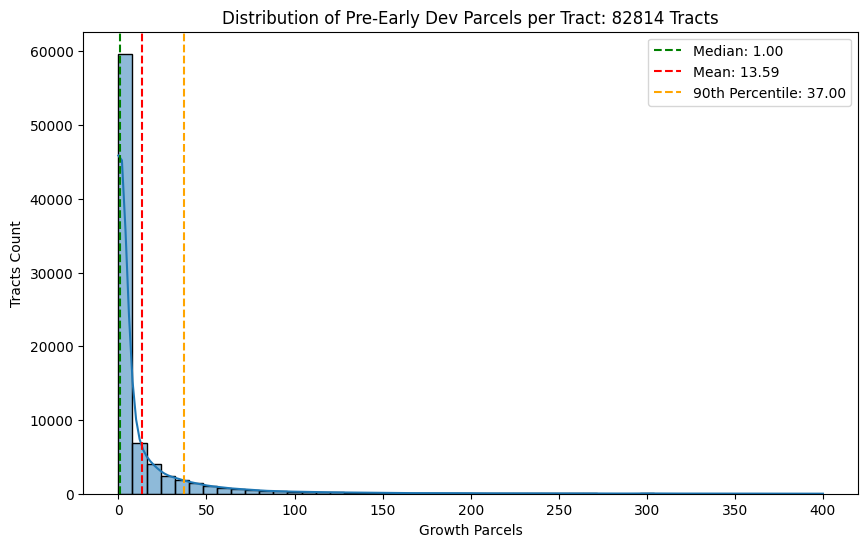

In [37]:
# Draw histrogram of growth_col
plt.figure(figsize=(10,6))
data = tract_df[tract_df[growth_col] <= 400][growth_col]
sns.histplot(data, bins=50, kde=True)
plt.axvline(data.median(), color='green', linestyle='--', label=f'Median: {data.median():.2f}')
plt.axvline(data.mean(), color='red', linestyle='--', label=f'Mean: {data.mean():.2f}')
plt.axvline(data.quantile(0.90), color='orange', linestyle='--', label=f'90th Percentile: {data.quantile(0.9):.2f}')
plt.legend()
plt.title(f"Distribution of Pre-Early Dev Parcels per Tract: {data.shape[0]} Tracts")
plt.xlabel("Growth Parcels")
plt.ylabel("Tracts Count")
plt.show()

In [48]:
# Correlation between growth_parcels and pre_early_dev_parcels
# First we need to merge tract_df_overall and tract_df on tract_id
merged = tract_df_overall[['tract_id', 'growth_parcels']].merge(
    tract_df[['tract_geoid', 'pre_early_dev_parcels']], 
    left_on='tract_id', right_on='tract_geoid', how='inner'
)

print(f"Merged tracts: {len(merged):,}")
print(f"Pearson correlation: {merged['growth_parcels'].corr(merged['pre_early_dev_parcels']):.3f}")
print(f"Spearman correlation: {merged['growth_parcels'].corr(merged['pre_early_dev_parcels'], method='spearman'):.3f}")
print("=" * 60)
print(f"Avg pre-early dev as % of growth: {(merged['pre_early_dev_parcels'] / merged['growth_parcels'].replace(0, np.nan)).mean():.2%}")

Merged tracts: 83,216
Pearson correlation: 0.660
Spearman correlation: 0.729
Avg pre-early dev as % of growth: 21.20%


##### Hotspot Calculation

In [85]:
# Pull in growth hotspots data from BigQuery
client = bigquery.Client(project=GCS_PROJECT_ID)

query = """
SELECT *EXCEPT(geom)
FROM `clgx-gis-app-dev-06e3.work_eprashar.TEU_parcel_agg_h3r7`
"""

df = client.query(query).to_arrow().to_pandas()
print(f"Dataframe shape: {df.shape}")
print("=" * 50)
print("Dataframe info:", df.info())
print("=" * 50)
df.head()

/home/eprashar_solutions_corelogic_com/.cache/pypoetry/virtualenvs/network-idx-10LC4-Te-py3.12/lib/python3.12/site-packages/google/cloud/bigquery/table.py:2086: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
  warnings.warn(


Dataframe shape: (505259, 10)
<class 'pandas.DataFrame'>
RangeIndex: 505259 entries, 0 to 505258
Data columns (total 10 columns):
 #   Column                   Non-Null Count   Dtype
---  ------                   --------------   -----
 0   h3_id                    505259 non-null  str  
 1   growth_parcels           505259 non-null  int64
 2   unique_locations         505259 non-null  int64
 3   landuse_change_count     505259 non-null  int64
 4   builder_developer_count  505259 non-null  int64
 5   building_permit_count    505259 non-null  int64
 6   new_clip_count           505259 non-null  int64
 7   parcel_split_count       505259 non-null  int64
 8   total_flags              505259 non-null  int64
 9   flags_minus_greatest     505259 non-null  int64
dtypes: int64(9), str(1)
memory usage: 45.8 MB
Dataframe info: None


,h3_id,growth_parcels,unique_locations,landuse_change_count,builder_developer_count,building_permit_count,new_clip_count,parcel_split_count,total_flags,flags_minus_greatest
0,872a89018ffffff,1,1,0,0,0,0,0,0,0
1,8728b269effffff,1,1,0,0,0,0,0,0,0
2,872a310c6ffffff,1,1,0,0,0,0,0,0,0
3,8744e0aabffffff,1,1,0,0,0,0,0,0,0
4,87278b78cffffff,1,1,0,0,0,0,0,0,0


In [62]:
# H3 cells without a flag
print(f"Total H3 cells: {len(df):,}")
print(f"H3 cells without a flag: {(df["total_flags"] == 0).sum():,}")

Total H3 cells: 505,259
H3 cells without a flag: 181,289


In [58]:
# Plot distribution of growth parcels
growth_col = 'growth_parcels'
print(df[growth_col].describe().round(2).to_string())
print(f"90th percentile: {df[growth_col].quantile(0.90):.2f}")
print(f"95th percentile: {df[growth_col].quantile(0.95):.2f}")
print(f"99th percentile: {df[growth_col].quantile(0.99):.2f}")
print(f"99.5th percentile: {df[growth_col].quantile(0.995):.2f}")
print("=" * 80)

count    505259.00
mean         12.49
std          71.76
min           1.00
25%           1.00
50%           3.00
75%           7.00
max        6129.00
90th percentile: 20.00
95th percentile: 40.00
99th percentile: 157.00
99.5th percentile: 273.00


In [86]:
# Plot distribution of growth parcels
growth_col = 'total_flags'
# df = df[df[growth_col] > 0] # doing this doesn't change key takeaways
print(df[growth_col].describe().round(2).to_string())
print(f"90th percentile: {df[growth_col].quantile(0.90):.2f}")
print(f"95th percentile: {df[growth_col].quantile(0.95):.2f}")
print(f"99th percentile: {df[growth_col].quantile(0.99):.2f}")
print(f"99.5th percentile: {df[growth_col].quantile(0.995):.2f}")
print("=" * 80)

count    505259.00
mean          7.83
std          71.14
min           0.00
25%           0.00
50%           1.00
75%           3.00
max        6129.00
90th percentile: 7.00
95th percentile: 16.00
99th percentile: 127.00
99.5th percentile: 264.00


In [87]:
# Check what percentile is a given threshold at
t = 50
pct = (df[growth_col] <= t).mean() * 100
print(f"Value {t} is at the {pct:.2f}th percentile")

Value 50 is at the 97.87th percentile


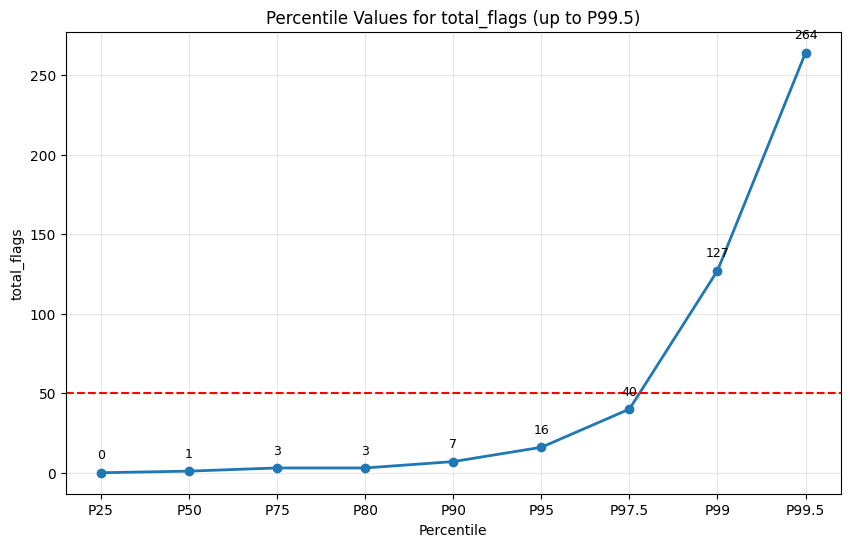

In [88]:
# Exclude P100 to focus on readable range
percentiles = [25, 50, 75, 80, 90, 95, 97.5, 99, 99.5]
values = [df[growth_col].quantile(p/100) for p in percentiles]

plt.figure(figsize=(10, 6))
x_pos = range(len(percentiles))  # Equal spacing
plt.plot(x_pos, values, marker='o', linewidth=2)
for i, (p, v) in enumerate(zip(percentiles, values)):
    plt.annotate(f'{v:.0f}', (i, v), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
plt.xlabel("Percentile")
plt.ylabel(growth_col)
plt.title(f"Percentile Values for {growth_col} (up to P99.5)")
plt.grid(True, alpha=0.3)
plt.xticks(x_pos, [f'P{p}' for p in percentiles])
plt.axhline(50, color='red', linestyle='--', label='Threshold = 50')
plt.show()

In [89]:
# Define metric: total_flags minus the max of the individual flag columns
df['flags_minus_max'] = df['total_flags'] - df[['landuse_change_count', 'builder_developer_count', 
                                                  'building_permit_count', 'new_clip_count', 
                                                  'parcel_split_count']].max(axis=1)

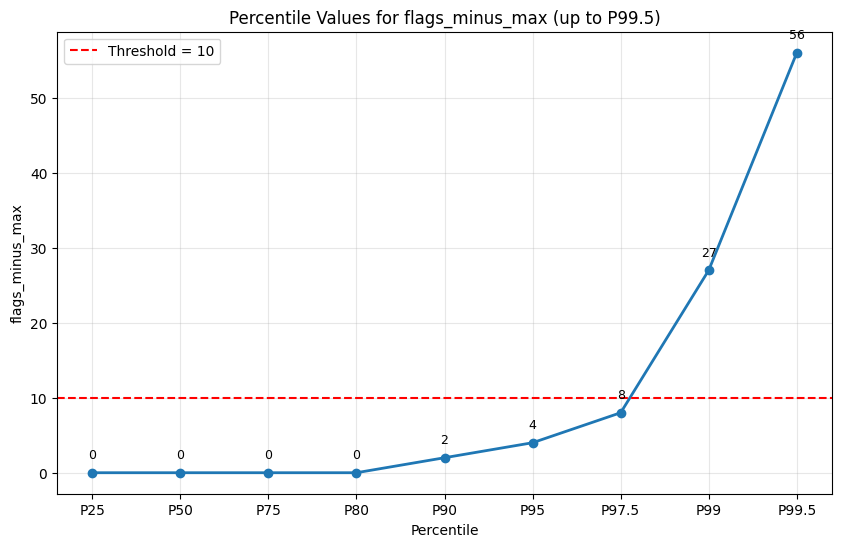

Value 10 is at the 97.94th percentile


In [90]:
# Percentile line chart for flags_minus_max
col_metric = 'flags_minus_max'
percentiles = [25, 50, 75, 80, 90, 95, 97.5, 99, 99.5]
values = [df[col_metric].quantile(p/100) for p in percentiles]

plt.figure(figsize=(10, 6))
x_pos = range(len(percentiles))
plt.plot(x_pos, values, marker='o', linewidth=2)
for i, (p, v) in enumerate(zip(percentiles, values)):
    plt.annotate(f'{v:.0f}', (i, v), textcoords="offset points", xytext=(0, 10), ha='center', fontsize=9)
plt.xlabel("Percentile")
plt.ylabel(col_metric)
plt.title(f"Percentile Values for {col_metric} (up to P99.5)")
plt.grid(True, alpha=0.3)
plt.xticks(x_pos, [f'P{p}' for p in percentiles])
plt.axhline(10, color='red', linestyle='--', label='Threshold = 10')
plt.legend()
plt.show()

# What percentile does threshold=10 fall at?
pct = (df[col_metric] <= 10).mean() * 100
print(f"Value 10 is at the {pct:.2f}th percentile")

<Axes: xlabel='growth_parcels', ylabel='Count'>

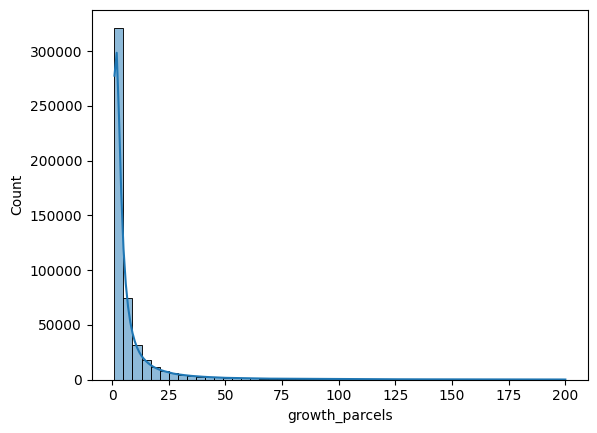

In [63]:
# Filtering for growth <= 50. Anything more than that is covered anyway and we don't need to view that distribution
df_filtered = df[df[growth_col] <= 200]
sns.histplot(df_filtered[growth_col], bins=50, kde=True)

In [ ]:
# Sum of growth parcels for different thresholds
def growth_parcels_covered(df,threshold):
    t = threshold
    print(f"Threshold 1: {t} growth parcels")
    print(f"Total growth parcels: {df[df['growth_parcels'] >= 0]['growth_parcels'].sum()}")
    print(f"Growth parcels when threshold = {t}: {df[df['growth_parcels']>=t]['growth_parcels'].sum()}")
    print(f"Percentage of growth parcels captured with threshold {t}: {df[df['growth_parcels']>=t]['growth_parcels'].sum() / df[df['growth_parcels'] >= 0]['growth_parcels'].sum() * 100:.2f}%")
    print("=" * 80)


# Check for different thresholds
thresholds = [50,40,30,25,20,15,10]
for t in thresholds:
    growth_parcels_covered(df, t)